In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re

In [7]:
def extract_metric_values(criteria: str, strings: list[str]) -> np.ndarray:
    """Extracts float values from strings like 'Validation Loss: 1.747406'."""
    # return [float(s.split(criteria)[1]) for s in strings]
    return np.array([float(s.split(criteria)[1]) for s in strings])


def parse_training_log(file_path: str):
    """Parses a model training log file to extract per-epoch metrics:

    - Training Loss
    - Training Macro F1
    - Validation Loss
    - Validation Macro F1

    Returns a pandas DataFrame with the extracted metrics.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    pattern = r"Training Macro F1: \d+\.\d+"
    training_macro_f1_values = re.findall(pattern, content, flags=re.IGNORECASE)
    tranining_macro_f1_values = extract_metric_values("Training Macro F1: ", training_macro_f1_values)

    pattern = r"Training Loss: \d+\.\d+"
    training_loss_values = re.findall(pattern, content, flags=re.IGNORECASE)
    training_loss_values = extract_metric_values("Training Loss: ", training_loss_values)

    pattern = r"Validation Macro F1: \d+\.\d+"
    validation_macro_f1_values = re.findall(pattern, content, flags=re.IGNORECASE)
    validation_macro_f1_values = extract_metric_values("Validation Macro F1: ", validation_macro_f1_values)

    pattern = r"Validation Loss: \d+\.\d+"
    validation_loss_values = re.findall(pattern, content, flags=re.IGNORECASE)
    validation_loss_values = extract_metric_values("Validation Loss: ", validation_loss_values)

    pattern = r"Test Macro F1: \d+\.\d+"
    test_macro_f1 = re.findall(pattern, content, flags=re.IGNORECASE)
    test_macro_f1 = extract_metric_values("Test Macro F1: ", test_macro_f1)[0]

    pattern = r"Test Loss: \d+\.\d+"
    test_loss = re.findall(pattern, content, flags=re.IGNORECASE)
    test_loss = extract_metric_values("Test Loss: ", test_loss)[0]

    pattern = r"Test F1 Scores:(.*?)Test Macro F1:"
    match = re.search(pattern, content, flags=re.DOTALL | re.IGNORECASE)

    if match:
        extracted_text = match.group(1).strip()

    pattern = r"(\w+) F1: (\d+\.\d+)"
    matches = re.findall(pattern, extracted_text, flags=re.IGNORECASE)
    class_f1_scores = {relation: float(score) for relation, score in matches}

    train_val_data = {
        "training_loss": training_loss_values,
        "training_f1": tranining_macro_f1_values,
        "validation_loss": validation_loss_values,
        "validation_f1": validation_macro_f1_values,
    }

    test_data = {
        "test_loss": test_loss,
        "test_macro_f1": test_macro_f1,
        "class_f1_scores": class_f1_scores,
    }

    return train_val_data, test_data

In [34]:
labels = ["after", "before", "includes", "is_included", "simultaneous", "vague"]
models = labels[:-1]
modes = ["cut", "only"]
seeds = [0, 1, 2]

In [35]:
cut_data = {}

for rel in labels[0:5]:
    scores = []
    for seed in seeds:
        path = f"../runs/cut_{rel}_seed_{seed}.out"
        _, test_metrics = parse_training_log(path)
        class_f1_scores = test_metrics["class_f1_scores"]
        scores.append(np.array(list(class_f1_scores.values())))
    cut_data[f"cut_{rel}"] = sum(scores) / len(seeds)

cut_df = pd.DataFrame(cut_data, index=labels)
cut_df.index.name = "class"


In [36]:
only_data = {}

for rel in labels[0:5]:
    scores = []
    for seed in seeds:
        path = f"../runs/only_{rel}_seed_{seed}.out"
        _, test_metrics = parse_training_log(path)
        class_f1_scores = test_metrics["class_f1_scores"]
        scores.append(np.array(list(class_f1_scores.values())))
    only_data[f"only_{rel}"] = sum(scores) / len(seeds)

only_df = pd.DataFrame(only_data, index=labels)
only_df.index.name = "class"
only_df

,only_after,only_before,only_includes,only_is_included,only_simultaneous
class,,,,,
after,0.469867,0.557733,0.686833,0.681400,0.660500
before,0.450133,0.591567,0.657400,0.653500,0.663067
includes,0.321067,0.479433,0.504600,0.460700,0.435533
is_included,0.380667,0.523800,0.580500,0.565567,0.558500
simultaneous,0.190200,0.295900,0.360067,0.350600,0.340167
vague,0.618000,0.661100,0.650300,0.627900,0.648067


In [37]:
scores = []
for seed in seeds:
    path = f"../runs/constraints_seed_{seed}.out"
    _, test_metrics = parse_training_log(path)
    class_f1_scores = test_metrics["class_f1_scores"]
    scores.append(np.array(list(class_f1_scores.values())))
constraints_data = sum(scores) / len(seeds)

scores = []
for seed in seeds:
    path = f"../runs/baseline_seed_{seed}.out"
    _, test_metrics = parse_training_log(path)
    class_f1_scores = test_metrics["class_f1_scores"]
    scores.append(np.array(list(class_f1_scores.values())))
baseline_data = sum(scores) / len(seeds)

scores = []
for seed in seeds:
    path = f"../runs/augmented_seed_{seed}.out"
    _, test_metrics = parse_training_log(path)
    class_f1_scores = test_metrics["class_f1_scores"]
    scores.append(np.array(list(class_f1_scores.values())))
augmented_data = sum(scores) / len(seeds)

general_data = {
    "constraints": constraints_data,
    "baseline": baseline_data,
    "augmented": augmented_data,
}   
print(general_data)

{'constraints': array([0.69756667, 0.6765    , 0.48926667, 0.58966667, 0.29403333,
       0.6384    ]), 'baseline': array([0.64293333, 0.63513333, 0.4723    , 0.50156667, 0.20206667,
       0.66763333]), 'augmented': array([0.65816667, 0.6634    , 0.46493333, 0.55973333, 0.32573333,
       0.6343    ])}


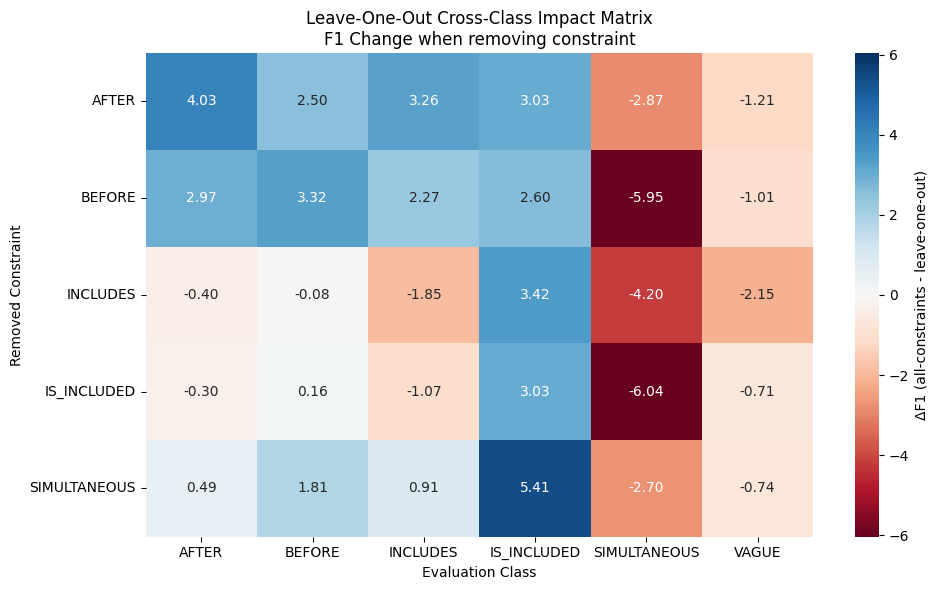

In [40]:
diff_data = cut_df.copy()

for model in models:
    diff_data[f"cut_{model}"] = general_data["constraints"] - cut_df[f"cut_{model}"]


# heatmap_data = diff_data.drop(columns=["class"]).T
heatmap_data = diff_data.drop(columns=["class"], errors='ignore').T
heatmap_data.columns = labels

heatmap_data.index = [idx.replace("cut_", "").upper() for idx in heatmap_data.index]
heatmap_data.columns = [col.upper() for col in heatmap_data.columns]

heatmap_data = heatmap_data * 100

diagonal_leave_out = np.diag(heatmap_data.values)



max_abs = np.abs(heatmap_data.values).max()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,
    cbar_kws={"label": "ΔF1 (all-constraints - leave-one-out)"},
)
plt.xlabel("Evaluation Class")
plt.ylabel("Removed Constraint")
plt.title("Leave-One-Out Cross-Class Impact Matrix\nF1 Change when removing constraint")
plt.tight_layout()
plt.show()

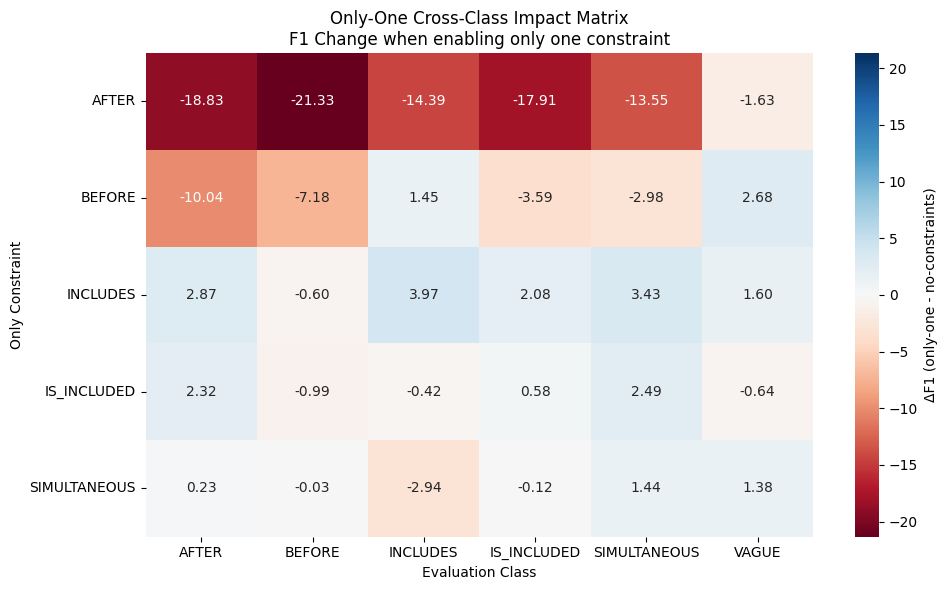

In [41]:
diff_data = only_df.copy()

for model in models:
    diff_data[f"only_{model}"] = only_df[f"only_{model}"] - general_data["augmented"]

heatmap_data = diff_data.drop(columns=["class"], errors='ignore').T
heatmap_data.columns = labels

heatmap_data.index = [idx.replace("only_", "").upper() for idx in heatmap_data.index]
heatmap_data.columns = [col.upper() for col in heatmap_data.columns]

heatmap_data = heatmap_data * 100

diagonal_only_one = np.diag(heatmap_data.values)



max_abs = np.abs(heatmap_data.values).max()


plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,


    
    cbar_kws={"label": "ΔF1 (only-one - no-constraints)"},
)
plt.xlabel("Evaluation Class")
plt.ylabel("Only Constraint")
plt.title("Only-One Cross-Class Impact Matrix\nF1 Change when enabling only one constraint")
plt.tight_layout()
plt.show()